# Laboratorio 10 - EDA

In [31]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [32]:
import sys
!{sys.executable} -m pip install openpyxl

In [33]:

# ── 1. CARGA DEL DATASET ─────────────────────────────────────
# Descarga desde: https://archive.ics.uci.edu/dataset/602/dry+bean+dataset
# Descomprime y coloca Dry_Bean_Dataset.xlsx en la misma carpeta

df = pd.read_excel('Dry_Bean_Dataset.xlsx')

print("=" * 50)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 50)
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\nColumnas: {list(df.columns)}")
print(f"\nVariable respuesta: Class")
print(f"Variables predictoras: {df.shape[1] - 1}")

INFORMACIÓN GENERAL DEL DATASET
Dimensiones: 13611 filas × 17 columnas

Columnas: ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']

Variable respuesta: Class
Variables predictoras: 16


In [34]:

# ── 2. TIPOS DE VARIABLES Y DIMENSIONALIDAD ──────────────────
print("\n" + "=" * 50)
print("TIPOS DE VARIABLES")
print("=" * 50)
print(df.dtypes)

print("\n" + "=" * 50)
print("ESTADÍSTICOS DESCRIPTIVOS")
print("=" * 50)
print(df.describe())


TIPOS DE VARIABLES
Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class                  str
dtype: object

ESTADÍSTICOS DESCRIPTIVOS
                Area     Perimeter  MajorAxisLength  MinorAxisLength  \
count   13611.000000  13611.000000     13611.000000     13611.000000   
mean    53048.284549    855.283459       320.141867       202.270714   
std     29324.095717    214.289696        85.694186        44.970091   
min     20420.000000    524.736000       183.601165       122.512653   
25%     36328.000000    703.523500       253.303633       175.848170   
50%     44652.000000    794.941000       296.883

In [35]:

# ── 3. VALORES FALTANTES Y DUPLICADOS ───────────────────────
print("\n" + "=" * 50)
print("CALIDAD DE DATOS")
print("=" * 50)
print(f"Valores nulos por columna:\n{df.isnull().sum()}")
print(f"\nTotal nulos: {df.isnull().sum().sum()}")
print(f"Filas duplicadas: {df.duplicated().sum()}")


CALIDAD DE DATOS
Valores nulos por columna:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

Total nulos: 0
Filas duplicadas: 68



BALANCE DE CLASES
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

Proporción:
Class
DERMASON    26.05
SIRA        19.37
SEKER       14.89
HOROZ       14.17
CALI        11.98
BARBUNYA     9.71
BOMBAY       3.84
Name: count, dtype: float64%


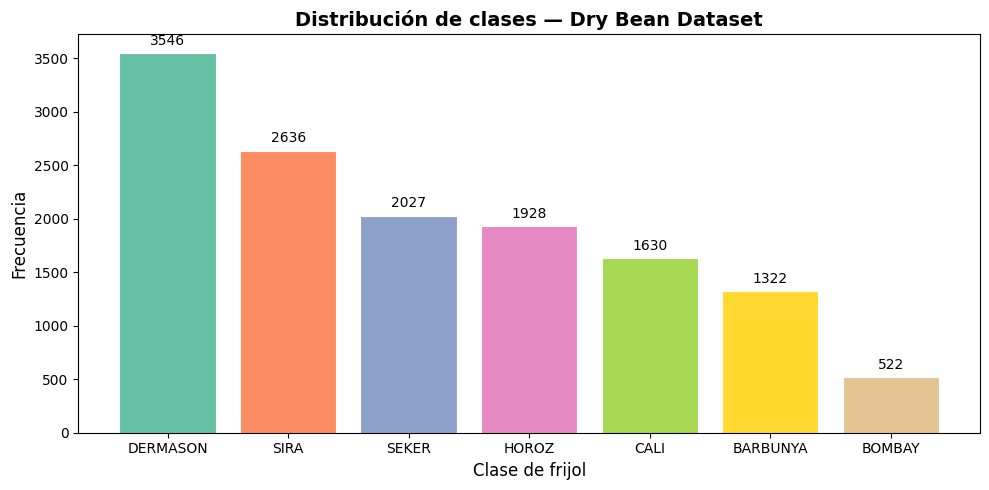

✓ Guardado: fig_01_balance_clases.png


In [36]:

# ── 4. BALANCE DE CLASES ─────────────────────────────────────
print("\n" + "=" * 50)
print("BALANCE DE CLASES")
print("=" * 50)
class_counts = df['Class'].value_counts()
print(class_counts)
print(f"\nProporción:\n{(class_counts / len(df) * 100).round(2)}%")

fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette("Set2", len(class_counts))
bars = ax.bar(class_counts.index, class_counts.values, color=colors, edgecolor='white', linewidth=0.8)
ax.set_title('Distribución de clases — Dry Bean Dataset', fontsize=14, fontweight='bold')
ax.set_xlabel('Clase de frijol', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(val), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('fig_01_balance_clases.png', dpi=150)
plt.show()
print("✓ Guardado: fig_01_balance_clases.png")

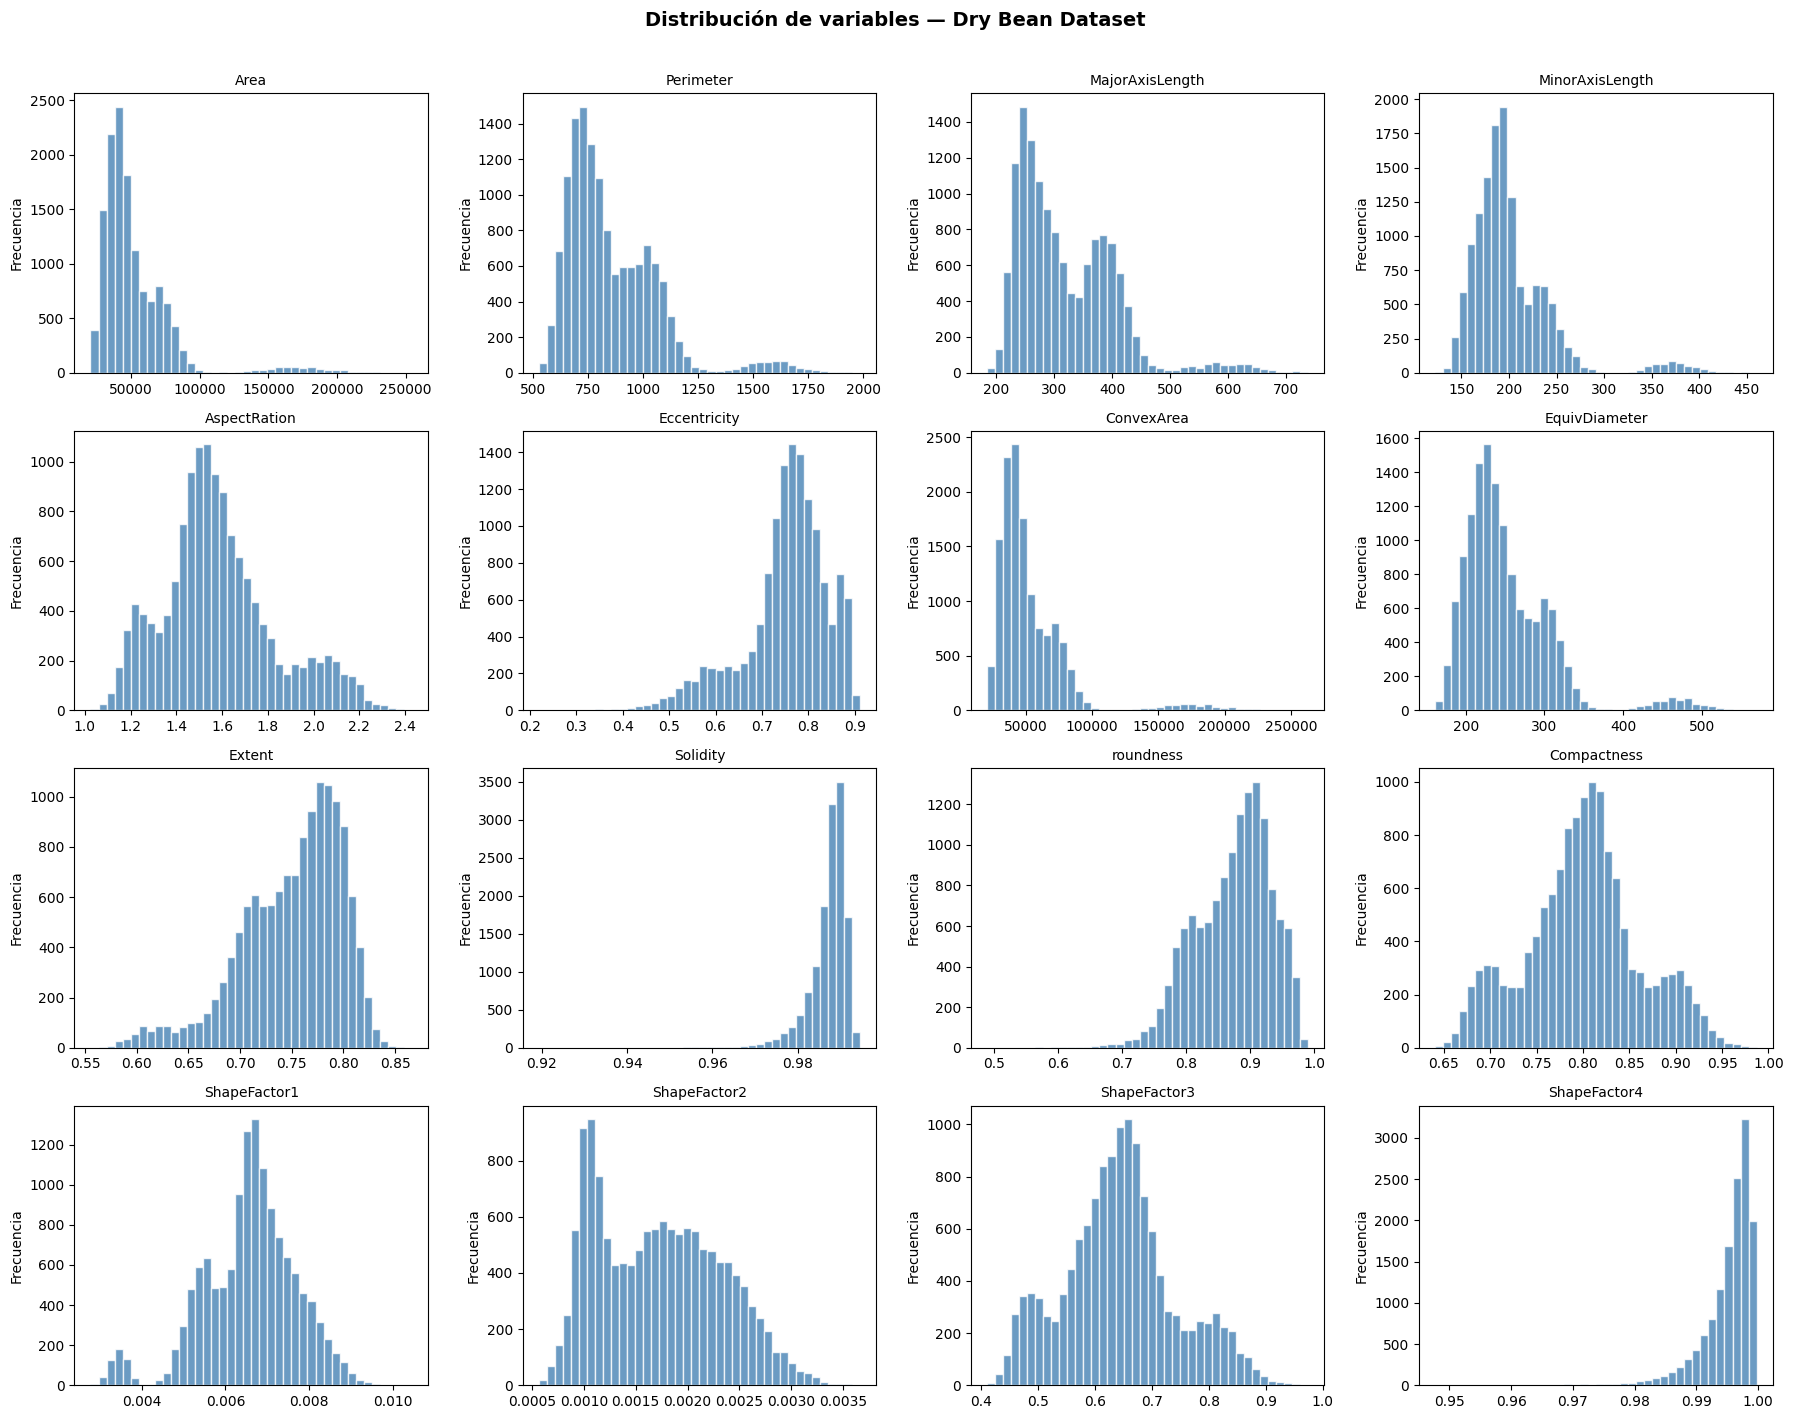

✓ Guardado: fig_02_distribuciones.png


In [37]:

# ── 5. DISTRIBUCIÓN DE CADA FEATURE ─────────────────────────
features = [c for c in df.columns if c != 'Class']

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
for i, feat in enumerate(features):
    axes[i].hist(df[feat], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_ylabel('Frecuencia')
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribución de variables — Dry Bean Dataset', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_02_distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Guardado: fig_02_distribuciones.png")

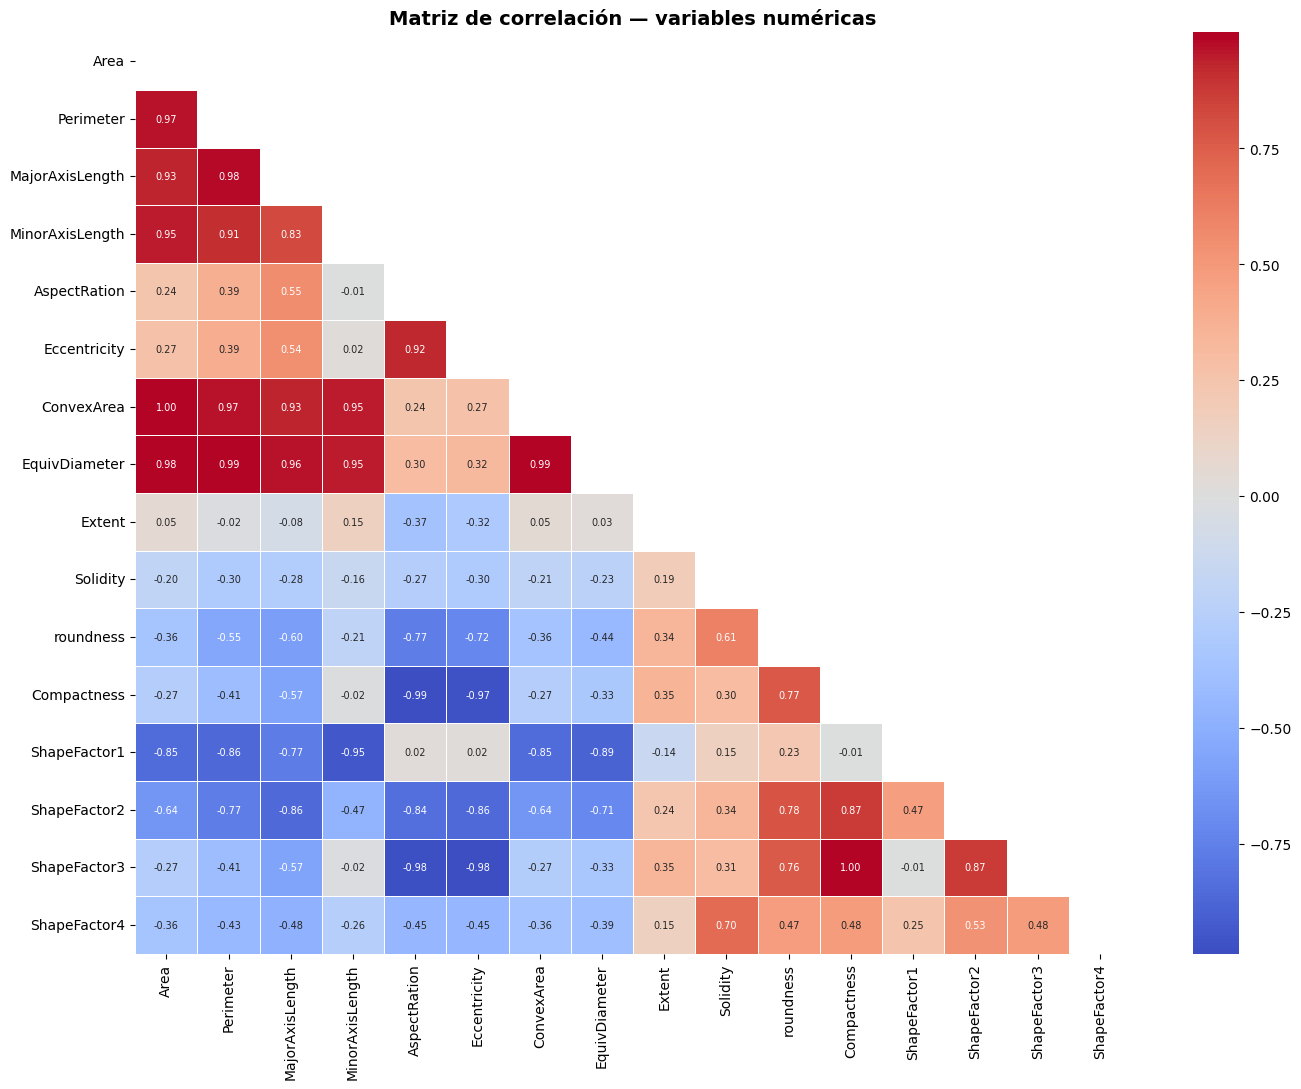

✓ Guardado: fig_03_correlacion.png


In [38]:

# ── 6. MATRIZ DE CORRELACIÓN ─────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 11))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 7})
ax.set_title('Matriz de correlación — variables numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_03_correlacion.png', dpi=150)
plt.show()
print("✓ Guardado: fig_03_correlacion.png")

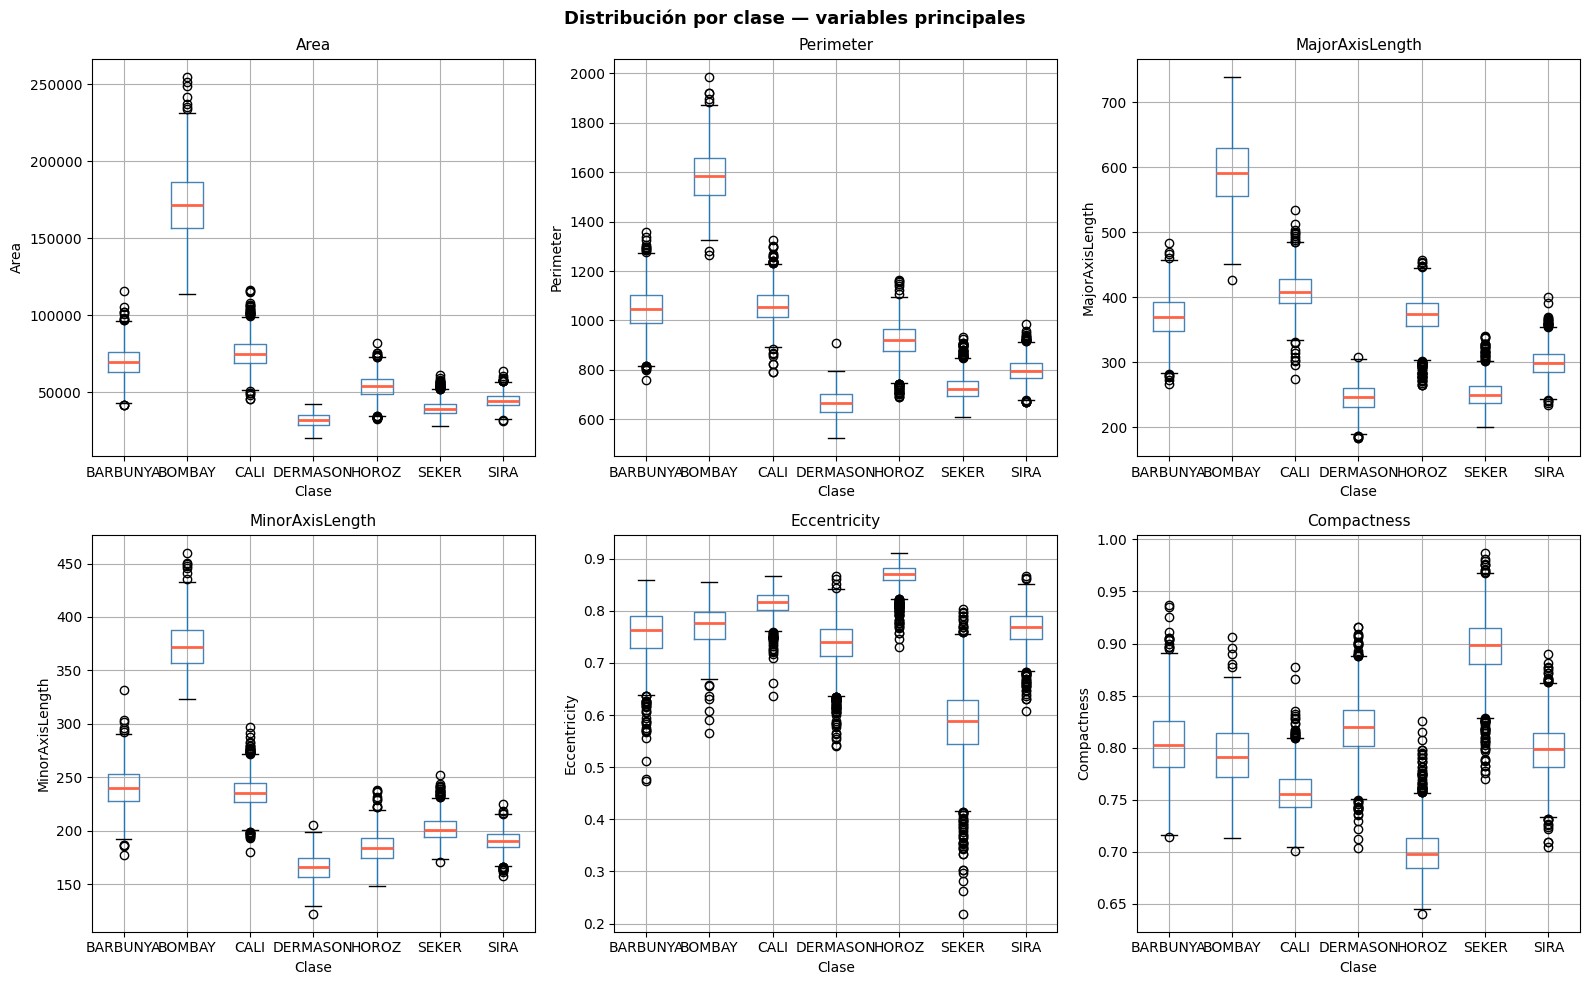

✓ Guardado: fig_04_boxplots_clase.png


In [39]:

# ── 7. BOXPLOTS POR CLASE (top 6 features más discriminativas) 
top_features = ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'Compactness']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, feat in enumerate(top_features):
    df.boxplot(column=feat, by='Class', ax=axes[i], 
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='tomato', linewidth=2))
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('Clase')
    axes[i].set_ylabel(feat)
plt.suptitle('Distribución por clase — variables principales', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_04_boxplots_clase.png', dpi=150)
plt.show()
print("✓ Guardado: fig_04_boxplots_clase.png")

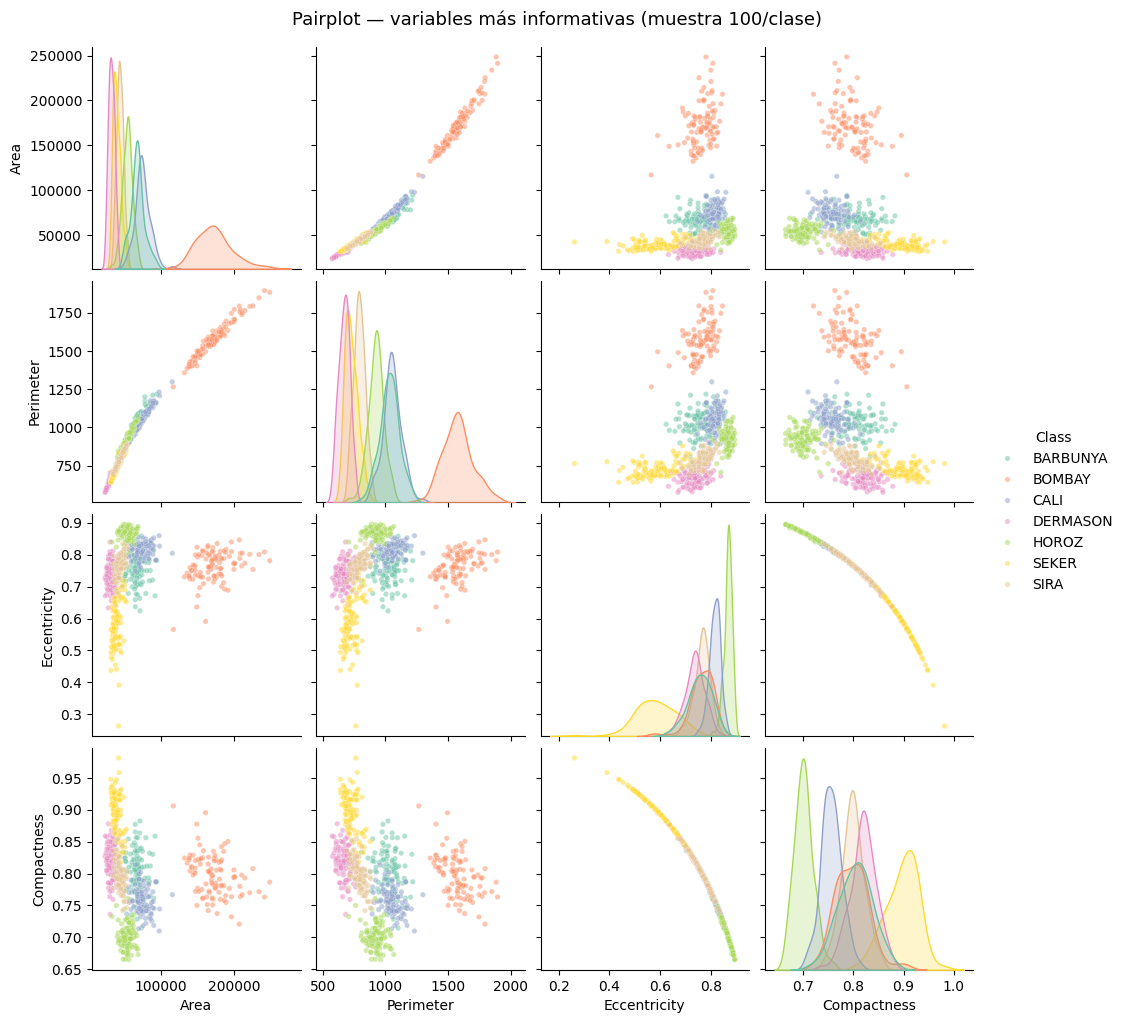

✓ Guardado: fig_05_pairplot.png


In [40]:
# ── 8. PAIRPLOT (muestra para velocidad) ────────────────────
sample = df.groupby('Class').sample(n=100, random_state=42).reset_index(drop=True)
pairplot_features = ['Area', 'Perimeter', 'Eccentricity', 'Compactness', 'Class']
g = sns.pairplot(sample[pairplot_features], hue='Class', 
                 palette='Set2', plot_kws={'alpha': 0.5, 's': 15})
g.fig.suptitle('Pairplot — variables más informativas (muestra 100/clase)', y=1.02, fontsize=13)
plt.savefig('fig_05_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Guardado: fig_05_pairplot.png")


Varianza explicada por PC1: 55.5%
Varianza explicada por PC2: 26.4%
Varianza total explicada:   81.9%


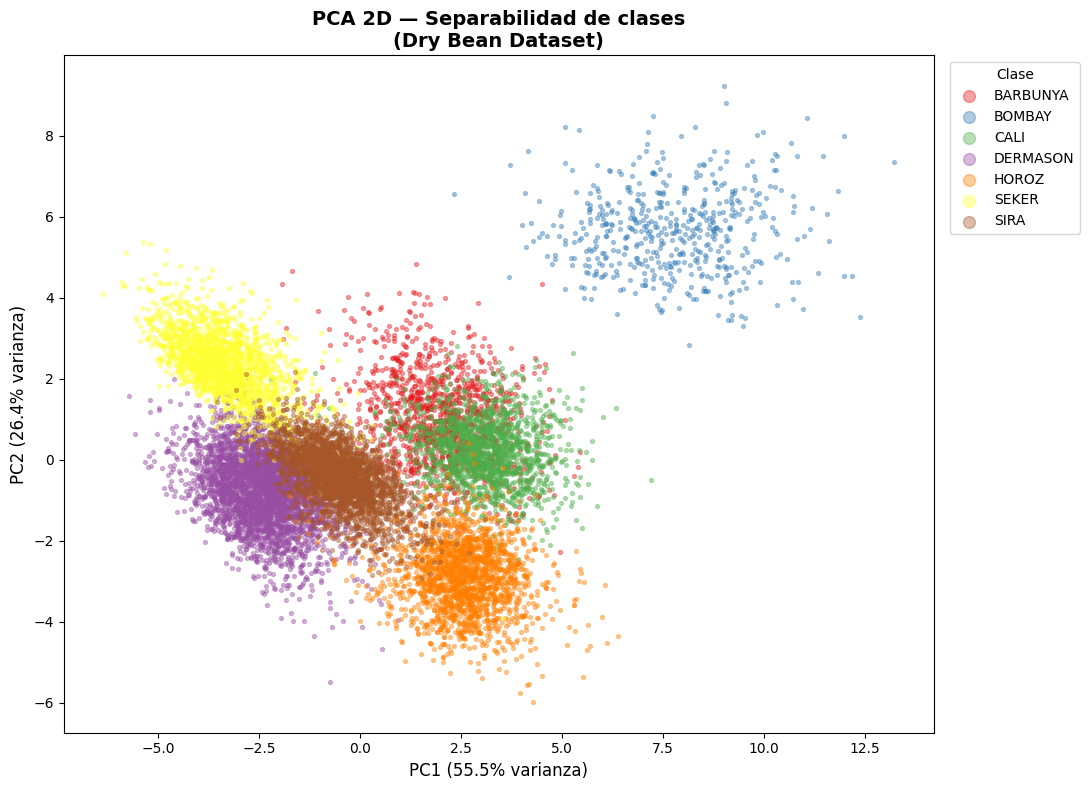

✓ Guardado: fig_06_pca2d.png

EDA COMPLETADO — todos los gráficos guardados


In [41]:

# ── 9. PCA 2D — SEPARABILIDAD DE CLASES ─────────────────────
le = LabelEncoder()
y_enc = le.fit_transform(df['Class'])
X_num = df[features].values

scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_num)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"\nVarianza explicada por PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Varianza explicada por PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Varianza total explicada:   {sum(pca.explained_variance_ratio_)*100:.1f}%")

fig, ax = plt.subplots(figsize=(11, 8))
palette = sns.color_palette("Set1", len(le.classes_))
for i, clase in enumerate(le.classes_):
    mask = y_enc == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=clase, alpha=0.4, s=8, color=palette[i])
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=12)
ax.set_title('PCA 2D — Separabilidad de clases\n(Dry Bean Dataset)', fontsize=14, fontweight='bold')
ax.legend(title='Clase', bbox_to_anchor=(1.01, 1), loc='upper left', markerscale=3)
plt.tight_layout()
plt.savefig('fig_06_pca2d.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Guardado: fig_06_pca2d.png")

print("\n" + "=" * 50)
print("EDA COMPLETADO — todos los gráficos guardados")
print("=" * 50)